# Кейс 7. Аддитивная модель по мотивам теоремы Колмогорова

Исследовательская работа по дисциплине «Функциональный анализ». Автор: Мирасов К. В., группа J3212.

## Введение

Рассматривается восстановление зависимости $y = f(x_1, \dots, x_p) + \varepsilon$ на единичном кубе $[0, 1]^p$ по конечной обучающей выборке. Прямое построение полной многомерной аппроксимации неустойчиво при росте числа признаков, поэтому используются модели на одномерных функциях, сохраняющие интерпретируемость вклада признаков.

Теорема Колмогорова о представлении непрерывной функции задаёт мотивацию: многомерная непрерывная функция выражается через суперпозиции функций одного аргумента и сложение,

$$
f(x_1, \dots, x_p) = \sum_{k=1}^{2p+1} h_k\!\Big(\sum_{i=1}^{p} \phi_{ik}(x_i)\Big).
$$

В работе используется вычислительно простой частный случай этой идеи, аддитивная модель: она не претендует на полноту теоремы, но даёт линейную по параметрам задачу после выбора базиса.

Цель работы состоит в построении аддитивной модели, оценке параметров по МНК и ridge, введении центрирования для идентифицируемости, сравнении с линейной и полной полиномиальной моделями и проверке поведения на данных с взаимодействиями. Эксперименты проведены на синтетических аддитивных данных, датасете Diabetes и синтетической неаддитивной задаче.


In [1]:
from __future__ import annotations

from dataclasses import dataclass
import json
from pathlib import Path
from typing import Callable

import matplotlib as mpl
import matplotlib.pyplot as plt
from IPython.display import display
import numpy as np
import pandas as pd
from scipy.interpolate import BSpline
from sklearn.datasets import load_diabetes
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, PolynomialFeatures

SEED: int = 42
N_SYNTHETIC: int = 900
N_NONADDITIVE: int = 900
TEST_SIZE: float = 0.25
M_MAIN: int = 12
M_REAL: int = 8
M_VALUES: tuple[int, ...] = tuple(range(4, 19))
LAMBDA_GRID: tuple[float, ...] = (0.0, 1e-6, 1e-4, 1e-3, 1e-2, 1e-1, 1.0)
NOISE_STD: float = 0.08
GRID_SIZE: int = 220

PROJECT_ROOT: Path = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
ASSETS_DIR: Path = PROJECT_ROOT / "reports" / "case7_additive_model" / "assets"
ASSETS_DIR.mkdir(parents=True, exist_ok=True)

PALETTE: dict[str, str] = {
    "data": "#9aa0a6",
    "truth": "#1f4e79",
    "model": "#c1121f",
    "alt": "#5a7d2a",
    "extra": "#b8860b",
}

mpl.rcParams.update({
    "figure.figsize": (7.0, 4.2),
    "figure.dpi": 120,
    "savefig.dpi": 200,
    "savefig.bbox": "tight",
    "savefig.pad_inches": 0.03,
    "svg.fonttype": "path",
    "font.family": "serif",
    "font.serif": ["Times New Roman", "DejaVu Serif"],
    "mathtext.fontset": "cm",
    "font.size": 11,
    "axes.titlesize": 12,
    "axes.labelsize": 11,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "grid.linewidth": 0.6,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.linewidth": 0.8,
    "legend.frameon": False,
    "legend.fontsize": 10,
    "lines.linewidth": 1.8,
    "lines.markersize": 4,
    "xtick.direction": "out",
    "ytick.direction": "out",
})

BasisFunction = Callable[[np.ndarray, int], np.ndarray]


def save_fig(fig: plt.Figure, name: str, *, raster: bool = False) -> None:
    """Save a figure to the report assets directory and show it inline."""
    ext = "png" if raster else "svg"
    fig.savefig(ASSETS_DIR / f"{name}.{ext}")
    display(fig)
    plt.close(fig)


def rmse(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    """Return root mean squared error for two one-dimensional arrays."""
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))


## Аддитивная модель и постановка задачи

Аддитивная модель представляет отклик суммой покомпонентных эффектов, каждый из которых разложен в конечном одномерном базисе:

$$
\hat{f}(x) = \beta_0 + \sum_{j=1}^{p} g_j(x_j), \qquad
g_j(t) = \sum_{m=1}^{M} a_{jm}\, \psi_m(t).
$$

После подстановки модель линейна по параметрам $\theta = (\beta_0, \{a_{jm}\})$:

$$
\hat{f}(x) = \beta_0 + \sum_{j=1}^{p} \sum_{m=1}^{M} a_{jm}\, \psi_m(x_j).
$$

Строка матрицы признаков объекта $x_i$ имеет вид $z_i = \big(1, \psi_1(x_{i1}), \dots, \psi_M(x_{ip})\big)$, так что $\hat{y}_i = z_i^{\top}\theta$, а обучение сводится к минимизации

$$
Q(\theta) = \sum_{i=1}^{\ell} \Big(y_i - \beta_0 - \sum_{j=1}^{p}\sum_{m=1}^{M} a_{jm}\,\psi_m(x_{ij})\Big)^2.
$$

Без ограничений разложение не единственно: постоянную можно переносить между $\beta_0$ и $g_j$. Поэтому вводится условие идентифицируемости

$$
\sum_{i=1}^{\ell} g_j(x_{ij}) = 0, \qquad j = 1, \dots, p.
$$

При фиксированном $M$ модель имеет $1 + pM$ параметров, что заметно меньше, чем у полной полиномиальной модели с взаимодействиями, и сохраняет графики $\hat{g}_j(t)$ как интерпретируемые частные зависимости.


## Базисные разложения

Реализованы три семейства одномерных базисов $\psi_m(t)$ на $[0, 1]$:

1. полиномиальный: $t, t^2, \dots, t^M$;
2. тригонометрический: чередование $\sin(2\pi k t)$ и $\cos(2\pi k t)$;
3. кубический B-сплайновый на равномерных узлах с краевой кратностью 4 (основной).

B-сплайны локальны: изменение одного коэффициента влияет лишь на ограниченную часть интервала, в отличие от глобальных полиномов, что делает их устойчивыми при умеренном росте $M$.


In [2]:
def poly_basis(t: np.ndarray, M: int) -> np.ndarray:
    """Return columns t^1, ..., t^M for values from [0, 1]."""
    values = np.asarray(t, dtype=float).reshape(-1)
    if M < 1:
        raise ValueError("M must be positive")
    return np.column_stack([values ** power for power in range(1, M + 1)])


def trig_basis(t: np.ndarray, M: int) -> np.ndarray:
    """Return alternating sine and cosine columns on [0, 1]."""
    values = np.asarray(t, dtype=float).reshape(-1)
    if M < 1:
        raise ValueError("M must be positive")
    columns: list[np.ndarray] = []
    for index in range(M):
        harmonic = index // 2 + 1
        angle = 2.0 * np.pi * harmonic * values
        columns.append(np.sin(angle) if index % 2 == 0 else np.cos(angle))
    return np.column_stack(columns)


def bspline_basis(t: np.ndarray, M: int, degree: int = 3) -> np.ndarray:
    """Return a clamped B-spline design matrix with M basis functions on [0, 1]."""
    values = np.clip(np.asarray(t, dtype=float).reshape(-1), 0.0, 1.0)
    if M <= degree:
        raise ValueError("For a cubic B-spline basis M must be at least degree + 1")
    interior_count = M - degree - 1
    interior = np.linspace(0.0, 1.0, interior_count + 2)[1:-1] if interior_count > 0 else np.array([])
    knots = np.concatenate([np.zeros(degree + 1), interior, np.ones(degree + 1)])
    matrix = BSpline.design_matrix(values, knots, degree, extrapolate=False).toarray()
    return np.asarray(matrix, dtype=float)


BASES: dict[str, BasisFunction] = {
    "poly": poly_basis,
    "trig": trig_basis,
    "bspline": bspline_basis,
}


## Блочная матрица, МНК и ridge

Матрица $Z$ состоит из столбца единиц и $p$ блоков по $M$ центрированных столбцов, по одному блоку на признак. Оценка МНК в невырожденном случае

$$
\hat{\theta} = (Z^{\top} Z)^{-1} Z^{\top} y
$$

вычисляется через `numpy.linalg.lstsq`, что корректно при линейной зависимости столбцов. Для устойчивости при больших $M$ применяется ridge

$$
\hat{\theta}_\lambda = (Z^{\top} Z + \lambda I')^{-1} Z^{\top} y,
$$

где $I'$ совпадает с единичной матрицей, кроме нулевого первого диагонального элемента, поэтому свободный член $\beta_0$ не штрафуется.


In [3]:
@dataclass(frozen=True)
class AdditiveFit:
    """Store fitted additive model parameters and training centering constants."""

    theta: np.ndarray
    col_means: np.ndarray
    basis: BasisFunction
    basis_name: str
    M: int
    lam: float
    n_features: int

    @property
    def n_params(self) -> int:
        """Return the number of fitted parameters."""
        return int(self.theta.size)


def build_design(
    X: np.ndarray,
    basis: BasisFunction,
    M: int,
    *,
    col_means: np.ndarray | None = None,
) -> tuple[np.ndarray, np.ndarray]:
    """Build Z = [1 | centered feature-wise basis blocks]."""
    values = np.asarray(X, dtype=float)
    if values.ndim != 2:
        raise ValueError("X must be a two-dimensional array")
    blocks = [basis(values[:, feature_index], M) for feature_index in range(values.shape[1])]
    raw = np.hstack(blocks)
    means = raw.mean(axis=0) if col_means is None else np.asarray(col_means, dtype=float)
    if means.shape != (raw.shape[1],):
        raise ValueError("col_means has incompatible shape")
    centered = raw - means
    intercept = np.ones((values.shape[0], 1), dtype=float)
    return np.hstack([intercept, centered]), means


def fit_ols(Z: np.ndarray, y: np.ndarray) -> np.ndarray:
    """Fit least squares parameters through numpy.linalg.lstsq."""
    theta, *_ = np.linalg.lstsq(np.asarray(Z, dtype=float), np.asarray(y, dtype=float), rcond=None)
    return theta


def fit_ridge(Z: np.ndarray, y: np.ndarray, lam: float) -> np.ndarray:
    """Fit ridge parameters without penalizing the intercept term."""
    design = np.asarray(Z, dtype=float)
    target = np.asarray(y, dtype=float)
    penalty = np.eye(design.shape[1], dtype=float)
    penalty[0, 0] = 0.0
    return np.linalg.solve(design.T @ design + lam * penalty, design.T @ target)


def fit_additive(
    X: np.ndarray,
    y: np.ndarray,
    *,
    basis: BasisFunction = bspline_basis,
    basis_name: str = "bspline",
    M: int = M_MAIN,
    lam: float = 0.0,
) -> AdditiveFit:
    """Fit an additive model with a selected basis and optional ridge penalty."""
    Z, col_means = build_design(X, basis, M)
    theta = fit_ridge(Z, y, lam) if lam > 0 else fit_ols(Z, y)
    return AdditiveFit(theta=theta, col_means=col_means, basis=basis, basis_name=basis_name, M=M, lam=lam, n_features=X.shape[1])


def predict_additive(model: AdditiveFit, X: np.ndarray) -> np.ndarray:
    """Predict responses for X with a fitted additive model."""
    Z, _ = build_design(X, model.basis, model.M, col_means=model.col_means)
    return Z @ model.theta


## Центрирование и восстановление компонент

В матрицу включаются центрированные по обучающей выборке столбцы $\psi_m(x_{ij}) - \bar{\psi}_{jm}$, где $\bar{\psi}_{jm} = \tfrac{1}{\ell}\sum_{i} \psi_m(x_{ij})$. Тогда автоматически

$$
\sum_{i=1}^{\ell} \sum_{m=1}^{M} a_{jm}\big(\psi_m(x_{ij}) - \bar{\psi}_{jm}\big) = 0,
$$

то есть выполняется условие идентифицируемости, а общий уровень уходит в $\beta_0$. Восстановленная компонента $\hat{g}_j(t) = \sum_{m} a_{jm}\big(\psi_m(t) - \bar{\psi}_{jm}\big)$ сопоставима с истинной функцией.


In [4]:
def recover_component(
    j: int,
    t_grid: np.ndarray,
    theta: np.ndarray,
    basis: BasisFunction,
    M: int,
    col_means: np.ndarray,
) -> np.ndarray:
    """Recover g_j(t) on a grid using train-centered basis columns."""
    if j < 0:
        raise ValueError("Component index must be non-negative")
    start = 1 + j * M
    stop = start + M
    coefficients = theta[start:stop]
    means = col_means[j * M:(j + 1) * M]
    return (basis(t_grid, M) - means) @ coefficients


def component_values_on_X(model: AdditiveFit, X: np.ndarray) -> np.ndarray:
    """Return fitted component values g_j(x_ij) for each object and feature."""
    values = np.asarray(X, dtype=float)
    components = np.empty((values.shape[0], model.n_features), dtype=float)
    for feature_index in range(model.n_features):
        components[:, feature_index] = recover_component(
            feature_index,
            values[:, feature_index],
            model.theta,
            model.basis,
            model.M,
            model.col_means,
        )
    return components


## Модели сравнения и подбор регуляризации

Линейная модель $\hat{y}_{\mathrm{lin}} = \beta_0 + \sum_{j} \beta_j x_j$ является частным случаем аддитивной при $g_j(t) = \beta_j t$. Полная полиномиальная модель строится через `PolynomialFeatures` и включает взаимодействия вида $x_1 x_2$ (степень 5 на синтетике, 2 на Diabetes и неаддитивной задаче). Параметр $\lambda$ выбирается по внутренней валидации обучающей части из сетки $\{0, 10^{-6}, 10^{-4}, 10^{-3}, 10^{-2}, 10^{-1}, 1\}$.


In [5]:
def fit_linear(X: np.ndarray, y: np.ndarray) -> np.ndarray:
    """Fit linear regression with a single intercept column."""
    design = np.hstack([np.ones((X.shape[0], 1), dtype=float), np.asarray(X, dtype=float)])
    return fit_ols(design, y)


def predict_linear(theta: np.ndarray, X: np.ndarray) -> np.ndarray:
    """Predict responses for a fitted linear regression."""
    design = np.hstack([np.ones((X.shape[0], 1), dtype=float), np.asarray(X, dtype=float)])
    return design @ theta


def fit_full_poly(X: np.ndarray, y: np.ndarray, degree: int = 2) -> tuple[np.ndarray, PolynomialFeatures]:
    """Fit a full polynomial regression with interactions up to the selected degree."""
    transformer = PolynomialFeatures(degree=degree, include_bias=True)
    design = transformer.fit_transform(np.asarray(X, dtype=float))
    return fit_ols(design, y), transformer


def predict_full_poly(theta: np.ndarray, transformer: PolynomialFeatures, X: np.ndarray) -> np.ndarray:
    """Predict responses for a fitted full polynomial regression."""
    return transformer.transform(np.asarray(X, dtype=float)) @ theta


def select_lambda(
    X: np.ndarray,
    y: np.ndarray,
    *,
    basis: BasisFunction,
    basis_name: str,
    M: int,
    seed: int,
) -> float:
    """Select ridge lambda by a validation split inside the training sample."""
    X_sub, X_val, y_sub, y_val = train_test_split(X, y, test_size=0.25, random_state=seed)
    best_lam = LAMBDA_GRID[0]
    best_score = np.inf
    for lam in LAMBDA_GRID:
        model = fit_additive(X_sub, y_sub, basis=basis, basis_name=basis_name, M=M, lam=lam)
        score = rmse(y_val, predict_additive(model, X_val))
        if score < best_score:
            best_score = score
            best_lam = lam
    return float(best_lam)


## Данные и метрики качества

Синтетическая аддитивная задача:

$$
y = \sin(2\pi x_1) + 0{,}5\,(x_2 - 0{,}5)^2 + e^{-3 x_3} + \varepsilon, \qquad \varepsilon \sim \mathcal{N}(0, 0{,}08^2),
$$

900 объектов, три признака на $[0, 1]$. Неаддитивная задача $y = x_1 x_2 + x_3 + \varepsilon$ содержит взаимодействие, не представимое суммой одномерных функций. Реальные данные: Diabetes (442 объекта, 10 признаков, min-max нормировка по train). Качество измеряется в MSE, RMSE и $R^2$ на отложенном тесте.


In [6]:
def additive_components_raw(X: np.ndarray) -> np.ndarray:
    """Return true additive component values for the synthetic additive task."""
    values = np.asarray(X, dtype=float)
    return np.column_stack([
        np.sin(2.0 * np.pi * values[:, 0]),
        0.5 * (values[:, 1] - 0.5) ** 2,
        np.exp(-3.0 * values[:, 2]),
    ])


def make_additive_data(n_samples: int, rng: np.random.Generator) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """Generate synthetic additive data on [0, 1]^3."""
    X = rng.uniform(0.0, 1.0, size=(n_samples, 3))
    signal = additive_components_raw(X).sum(axis=1)
    y = signal + rng.normal(0.0, NOISE_STD, size=n_samples)
    return X, y, signal


def make_nonadditive_data(n_samples: int, rng: np.random.Generator) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """Generate a synthetic task with a product interaction x_1 x_2."""
    X = rng.uniform(0.0, 1.0, size=(n_samples, 3))
    signal = X[:, 0] * X[:, 1] + X[:, 2]
    y = signal + rng.normal(0.0, NOISE_STD, size=n_samples)
    return X, y, signal


def centered_true_components(t_grid: np.ndarray, X_train: np.ndarray) -> list[np.ndarray]:
    """Return true component curves centered by their train-sample means."""
    grid = np.asarray(t_grid, dtype=float)
    train_components = additive_components_raw(X_train)
    raw_curves = [
        np.sin(2.0 * np.pi * grid),
        0.5 * (grid - 0.5) ** 2,
        np.exp(-3.0 * grid),
    ]
    return [curve - train_components[:, index].mean() for index, curve in enumerate(raw_curves)]


def metric_record(dataset: str, model: str, y_true: np.ndarray, y_pred: np.ndarray, n_params: int) -> dict[str, float | int | str]:
    """Return a table row with MSE, RMSE, R2 and parameter count."""
    mse = float(mean_squared_error(y_true, y_pred))
    return {
        "Датасет": dataset,
        "Модель": model,
        "MSE": mse,
        "RMSE": float(np.sqrt(mse)),
        "R2": float(r2_score(y_true, y_pred)),
        "Параметры": int(n_params),
    }


def format_metrics(df: pd.DataFrame) -> pd.DataFrame:
    """Return a rounded copy of a metrics table for notebook display."""
    rounded = df.copy()
    for column in ["MSE", "RMSE", "R2", "RMSE test", "R2 test"]:
        if column in rounded.columns:
            rounded[column] = rounded[column].map(lambda value: f"{value:.4f}")
    return rounded


## Функции визуализации

Ниже определены функции построения рисунков; каждая возвращает объект `Figure`. Вспомогательная функция `save_fig` показывает фигуру в ноутбуке и сохраняет её в `assets/` (диаграмма «прогноз против факта» сохраняется в растровом виде, остальные рисунки в SVG).


In [7]:
def plot_true_components(t_grid: np.ndarray, truth_curves: list[np.ndarray]) -> plt.Figure:
    """Plot centered true additive components."""
    fig, axes = plt.subplots(1, 3, figsize=(9.2, 2.8), sharex=True)
    for index, ax in enumerate(axes):
        ax.plot(t_grid, truth_curves[index], color=PALETTE["truth"], label="истинная")
        ax.set_xlabel("$t$")
        ax.set_ylabel(f"$g_{index + 1}(t)$")
        ax.text(0.03, 0.92, f"({chr(1072 + index)})", transform=ax.transAxes)
    axes[0].legend(loc="best")
    fig.tight_layout()
    return fig


def plot_basis(t_grid: np.ndarray, M: int) -> plt.Figure:
    """Plot selected B-spline basis functions."""
    fig, ax = plt.subplots(figsize=(7.0, 4.0))
    basis_values = bspline_basis(t_grid, M)
    for index in range(M):
        ax.plot(t_grid, basis_values[:, index], color=PALETTE["truth"], alpha=0.35 + 0.55 * index / max(M - 1, 1))
    ax.set_xlabel("$t$")
    ax.set_ylabel("$\\psi_m(t)$")
    ax.set_title("Кубические B-сплайны")
    return fig


def plot_design_matrix(Z: np.ndarray, n_features: int, M: int) -> plt.Figure:
    """Plot the block structure of the additive design matrix."""
    rows = min(90, Z.shape[0])
    fig, ax = plt.subplots(figsize=(7.2, 4.2))
    image = ax.imshow(Z[:rows, :], aspect="auto", cmap="Greys", interpolation="nearest")
    ax.axvline(0.5, color=PALETTE["model"], linewidth=0.9)
    for feature_index in range(1, n_features):
        ax.axvline(0.5 + feature_index * M, color=PALETTE["alt"], linewidth=0.9)
    tick_positions = [0] + [1 + feature_index * M + (M - 1) / 2 for feature_index in range(n_features)]
    tick_labels = ["1"] + [f"$x_{feature_index + 1}$" for feature_index in range(n_features)]
    ax.set_xticks(tick_positions, tick_labels)
    ax.set_xlabel("блоки признаков")
    ax.set_ylabel("объекты обучающей выборки")
    fig.colorbar(image, ax=ax, fraction=0.035, pad=0.02, label="значение")
    return fig


def plot_recovered_components(
    t_grid: np.ndarray,
    truth_curves: list[np.ndarray],
    model: AdditiveFit,
) -> plt.Figure:
    """Plot recovered additive components against centered truth."""
    fig, axes = plt.subplots(1, 3, figsize=(9.2, 2.8), sharex=True)
    for index, ax in enumerate(axes):
        recovered = recover_component(index, t_grid, model.theta, model.basis, model.M, model.col_means)
        ax.plot(t_grid, truth_curves[index], color=PALETTE["truth"], label="истинная")
        ax.plot(t_grid, recovered, color=PALETTE["model"], linestyle="--", label="оценка")
        ax.set_xlabel("$t$")
        ax.set_ylabel(f"$g_{index + 1}(t)$")
        ax.text(0.03, 0.92, f"({chr(1072 + index)})", transform=ax.transAxes)
    axes[0].legend(loc="best")
    fig.tight_layout()
    return fig


In [8]:
def plot_model_comparison(metrics_df: pd.DataFrame) -> plt.Figure:
    """Plot RMSE and R2 for model comparison on additive data."""
    subset = metrics_df[metrics_df["Датасет"] == "Синтетические аддитивные"].reset_index(drop=True)
    colors = [PALETTE["data"], PALETTE["model"], PALETTE["alt"]]
    fig, axes = plt.subplots(1, 2, figsize=(8.2, 3.6))
    axes[0].bar(subset["Модель"], subset["RMSE"], color=colors)
    axes[0].set_ylabel("RMSE")
    axes[0].tick_params(axis="x", rotation=20)
    axes[1].bar(subset["Модель"], subset["R2"], color=colors)
    axes[1].set_ylabel("$R^2$")
    axes[1].tick_params(axis="x", rotation=20)
    for ax in axes:
        ax.set_xlabel("модель")
    fig.tight_layout()
    return fig


def plot_error_vs_M(error_df: pd.DataFrame) -> plt.Figure:
    """Plot train and test RMSE against the number of basis functions."""
    fig, ax = plt.subplots(figsize=(7.0, 4.2))
    ax.plot(error_df["M"], error_df["RMSE train"], marker="o", color=PALETTE["alt"], label="train")
    ax.plot(error_df["M"], error_df["RMSE test"], marker="s", color=PALETTE["model"], label="test")
    ax.axvspan(5, 12, color=PALETTE["truth"], alpha=0.08, label="разумный диапазон")
    ax.set_xlabel("число базисных функций $M$")
    ax.set_ylabel("RMSE")
    ax.legend(loc="best")
    return fig


def plot_pred_vs_true(y_true: np.ndarray, y_pred: np.ndarray) -> plt.Figure:
    """Plot predicted against observed target values."""
    fig, ax = plt.subplots(figsize=(5.0, 5.0))
    ax.scatter(y_true, y_pred, s=16, alpha=0.55, color=PALETTE["data"], edgecolors="none")
    low = float(min(y_true.min(), y_pred.min()))
    high = float(max(y_true.max(), y_pred.max()))
    ax.plot([low, high], [low, high], color=PALETTE["truth"], label="идеальный прогноз")
    ax.set_xlabel("факт")
    ax.set_ylabel("прогноз")
    ax.legend(loc="best")
    ax.set_aspect("equal", adjustable="box")
    return fig


def plot_nonadditive(
    additive_model: AdditiveFit,
    full_theta: np.ndarray,
    full_transformer: PolynomialFeatures,
) -> plt.Figure:
    """Plot residual surfaces for additive and full models on an interaction task."""
    axis = np.linspace(0.0, 1.0, 90)
    x1_grid, x2_grid = np.meshgrid(axis, axis)
    grid = np.column_stack([x1_grid.ravel(), x2_grid.ravel(), np.full(x1_grid.size, 0.5)])
    truth = (grid[:, 0] * grid[:, 1] + grid[:, 2]).reshape(x1_grid.shape)
    additive_residual = (predict_additive(additive_model, grid).reshape(x1_grid.shape) - truth)
    full_residual = (predict_full_poly(full_theta, full_transformer, grid).reshape(x1_grid.shape) - truth)
    vmax = float(max(np.abs(additive_residual).max(), np.abs(full_residual).max()))

    fig = plt.figure(figsize=(10.4, 3.1), constrained_layout=True)
    grid_spec = fig.add_gridspec(1, 5, width_ratios=[1.0, 0.045, 1.0, 1.0, 0.045], wspace=0.28)
    axes = [fig.add_subplot(grid_spec[0, 0]), fig.add_subplot(grid_spec[0, 2]), fig.add_subplot(grid_spec[0, 3])]
    cax_truth = fig.add_subplot(grid_spec[0, 1])
    cax_residual = fig.add_subplot(grid_spec[0, 4])
    first = axes[0].imshow(truth, extent=(0, 1, 0, 1), origin="lower", aspect="auto", cmap="viridis")
    axes[0].set_title("истинная поверхность")
    second = axes[1].imshow(additive_residual, extent=(0, 1, 0, 1), origin="lower", aspect="auto", cmap="coolwarm", vmin=-vmax, vmax=vmax)
    axes[1].set_title("остаток аддитивной")
    axes[2].imshow(full_residual, extent=(0, 1, 0, 1), origin="lower", aspect="auto", cmap="coolwarm", vmin=-vmax, vmax=vmax)
    axes[2].set_title("остаток полной")
    for ax in axes:
        ax.set_xlabel("$x_1$")
        ax.set_ylabel("$x_2$")
    axes[1].set_ylabel("")
    axes[2].set_ylabel("")
    fig.colorbar(first, cax=cax_truth)
    fig.colorbar(second, cax=cax_residual, label="ошибка")
    return fig


## Проверка корректности реализации

Контролируются два инварианта: сумма центрированных компонент на обучении равна нулю с точностью до $10^{-8}$, а на линейных данных аддитивная модель с $M = 1$ и полиномиальным базисом совпадает с явной линейной моделью.


In [9]:
rng = np.random.default_rng(SEED)
X_check, y_check, _ = make_additive_data(220, rng)
check_model = fit_additive(X_check, y_check, basis=bspline_basis, basis_name="bspline", M=M_MAIN, lam=1e-4)
component_sums = component_values_on_X(check_model, X_check).sum(axis=0)
max_centering_error = float(np.max(np.abs(component_sums)))
assert max_centering_error < 1e-8

X_linear = rng.uniform(0.0, 1.0, size=(260, 4))
linear_theta_true = np.array([0.7, -1.2, 0.5, 2.0, -0.4])
y_linear = linear_theta_true[0] + X_linear @ linear_theta_true[1:]
X_linear_train, X_linear_test, y_linear_train, _ = train_test_split(
    X_linear, y_linear, test_size=TEST_SIZE, random_state=SEED
)
additive_linear = fit_additive(X_linear_train, y_linear_train, basis=poly_basis, basis_name="poly", M=1, lam=0.0)
linear_model = fit_linear(X_linear_train, y_linear_train)
linear_difference = float(np.max(np.abs(
    predict_additive(additive_linear, X_linear_test) - predict_linear(linear_model, X_linear_test)
)))
assert linear_difference < 1e-10

checks_df = pd.DataFrame([
    {"Проверка": "суммы центрированных компонент", "Значение": max_centering_error, "Порог": 1e-8},
    {"Проверка": "совпадение с линейной моделью", "Значение": linear_difference, "Порог": 1e-10},
])
checks_df


,Проверка,Значение,Порог
0,суммы центрированных компонент,7.993606e-15,1.000000e-08
1,совпадение с линейной моделью,2.220446e-15,1.000000e-10


## Эксперимент 1. Синтетические аддитивные данные

Подбирается $\lambda$, обучается аддитивная модель на B-сплайнах, строятся истинные и восстановленные компоненты $\hat{g}_j$, базис $\psi_m$, блочная структура матрицы $Z$ и сравнение трёх моделей по качеству.


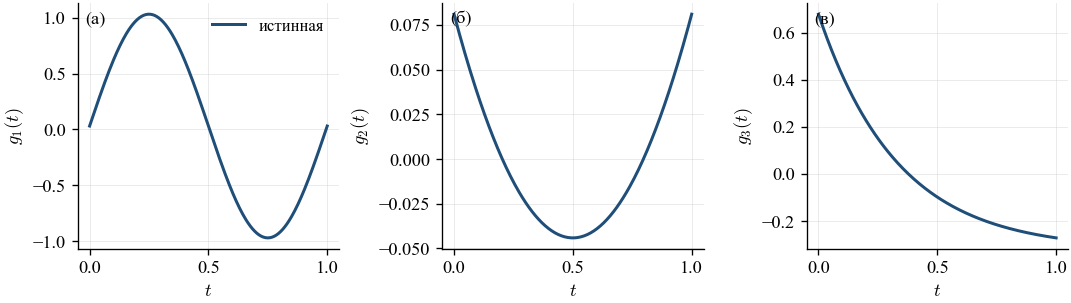

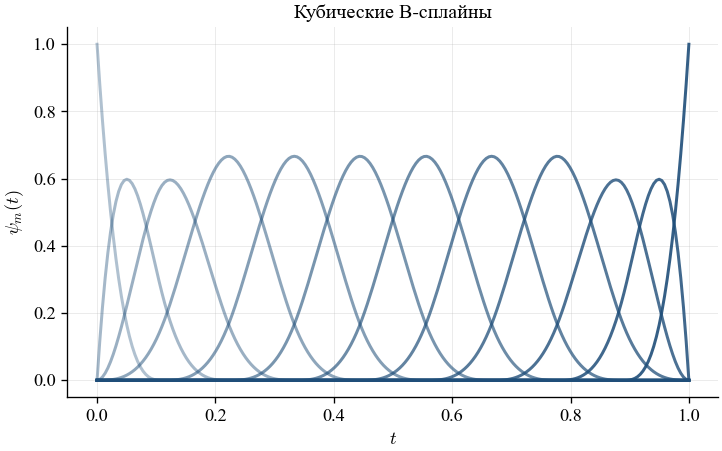

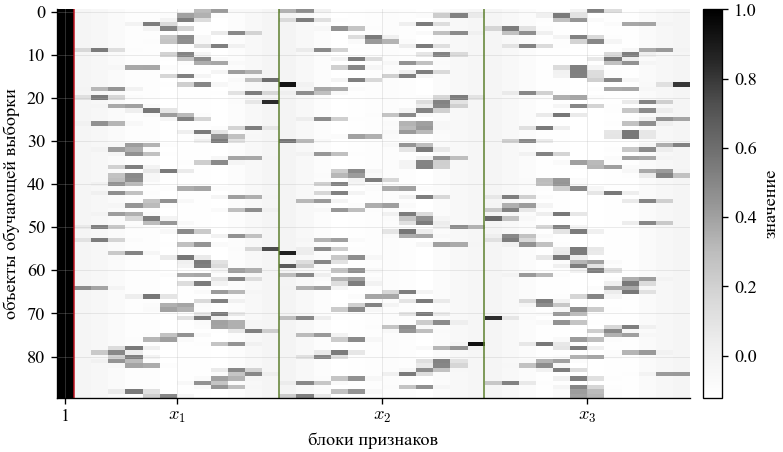

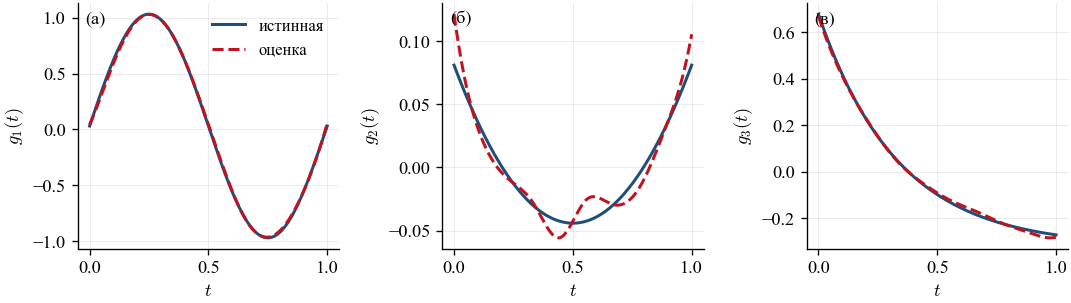

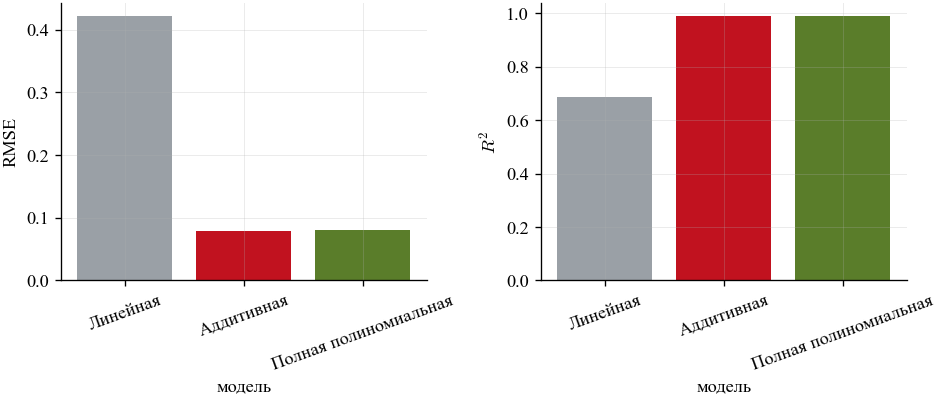

,Датасет,Модель,MSE,RMSE,R2,Параметры
0,Синтетические аддитивные,Линейная,0.1777,0.4215,0.6860,4
1,Синтетические аддитивные,Аддитивная,0.0061,0.0781,0.9892,37
2,Синтетические аддитивные,Полная полиномиальная,0.0065,0.0804,0.9886,56


In [10]:
rng = np.random.default_rng(SEED)
X_add, y_add, signal_add = make_additive_data(N_SYNTHETIC, rng)
X_add_train, X_add_test, y_add_train, y_add_test = train_test_split(
    X_add, y_add, test_size=TEST_SIZE, random_state=SEED
)

t_grid = np.linspace(0.0, 1.0, GRID_SIZE)
truth_curves = centered_true_components(t_grid, X_add_train)
additive_lam = select_lambda(
    X_add_train,
    y_add_train,
    basis=bspline_basis,
    basis_name="bspline",
    M=M_MAIN,
    seed=SEED,
)
additive_model = fit_additive(
    X_add_train,
    y_add_train,
    basis=bspline_basis,
    basis_name="bspline",
    M=M_MAIN,
    lam=additive_lam,
)
Z_add_train, _ = build_design(X_add_train, bspline_basis, M_MAIN, col_means=additive_model.col_means)

save_fig(plot_true_components(t_grid, truth_curves), "fig_true_components")
save_fig(plot_basis(t_grid, M_MAIN), "fig_basis")
save_fig(plot_design_matrix(Z_add_train, X_add_train.shape[1], M_MAIN), "fig_design_matrix")
save_fig(plot_recovered_components(t_grid, truth_curves, additive_model), "fig_recovered_components")

linear_theta = fit_linear(X_add_train, y_add_train)
full_theta, full_transformer = fit_full_poly(X_add_train, y_add_train, degree=5)

model_metrics = pd.DataFrame([
    metric_record("Синтетические аддитивные", "Линейная", y_add_test, predict_linear(linear_theta, X_add_test), linear_theta.size),
    metric_record("Синтетические аддитивные", "Аддитивная", y_add_test, predict_additive(additive_model, X_add_test), additive_model.n_params),
    metric_record("Синтетические аддитивные", "Полная полиномиальная", y_add_test, predict_full_poly(full_theta, full_transformer, X_add_test), full_theta.size),
])
save_fig(plot_model_comparison(model_metrics), "fig_model_comparison")
format_metrics(model_metrics)


## Эксперимент 2. Сложность базиса и выбор семейства

Перебирается число базисных функций $M = 4, \dots, 18$ и сравниваются три семейства базисов при сопоставимом $M$. Анализируется компромисс смещения и переобучения по train и test RMSE.


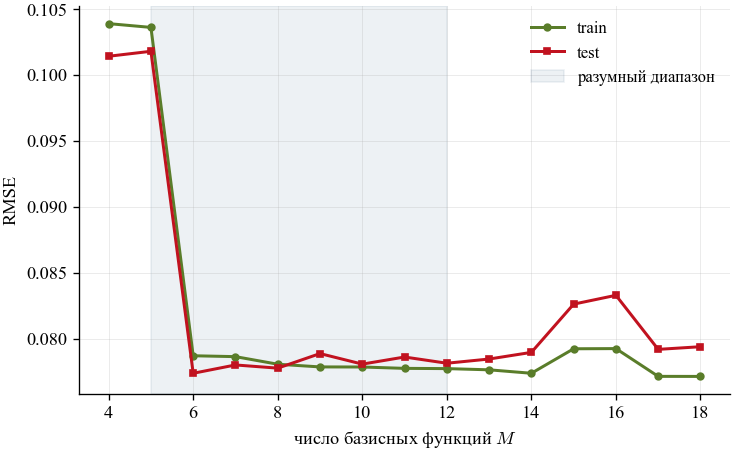

(   M  lambda  RMSE train  RMSE test
 0  4    0.01    0.103916   0.101438
 1  5    0.10    0.103629   0.101815
 2  6    0.00    0.078699   0.077368
 3  7    0.00    0.078632   0.078001
 4  8    0.10    0.078056   0.077759,
                 Базис   M    lambda RMSE test R2 test
 0      Полиномиальный  12  0.000001    0.0777  0.9893
 1  Тригонометрический  12  0.000000    0.1184  0.9752
 2           B-сплайны  12  0.100000    0.0781  0.9892)

In [11]:
error_rows: list[dict[str, float | int]] = []
for M in M_VALUES:
    lam = select_lambda(X_add_train, y_add_train, basis=bspline_basis, basis_name="bspline", M=M, seed=SEED + M)
    model = fit_additive(X_add_train, y_add_train, basis=bspline_basis, basis_name="bspline", M=M, lam=lam)
    error_rows.append({
        "M": M,
        "lambda": lam,
        "RMSE train": rmse(y_add_train, predict_additive(model, X_add_train)),
        "RMSE test": rmse(y_add_test, predict_additive(model, X_add_test)),
    })
error_vs_M = pd.DataFrame(error_rows)
save_fig(plot_error_vs_M(error_vs_M), "fig_error_vs_M")

basis_rows: list[dict[str, float | int | str]] = []
for basis_name, basis_fn, basis_M in [
    ("Полиномиальный", poly_basis, M_MAIN),
    ("Тригонометрический", trig_basis, M_MAIN),
    ("B-сплайны", bspline_basis, M_MAIN),
]:
    lam = select_lambda(X_add_train, y_add_train, basis=basis_fn, basis_name=basis_name, M=basis_M, seed=SEED + 100)
    model = fit_additive(X_add_train, y_add_train, basis=basis_fn, basis_name=basis_name, M=basis_M, lam=lam)
    basis_rows.append({
        "Базис": basis_name,
        "M": basis_M,
        "lambda": lam,
        "RMSE test": rmse(y_add_test, predict_additive(model, X_add_test)),
        "R2 test": float(r2_score(y_add_test, predict_additive(model, X_add_test))),
    })
basis_comparison = pd.DataFrame(basis_rows)
error_vs_M.head(), format_metrics(basis_comparison)


## Эксперимент 3. Реальный датасет Diabetes

Аддитивная модель сравнивается с линейной и полной полиномиальной на отложенном тесте Diabetes; строится диаграмма «прогноз против факта».


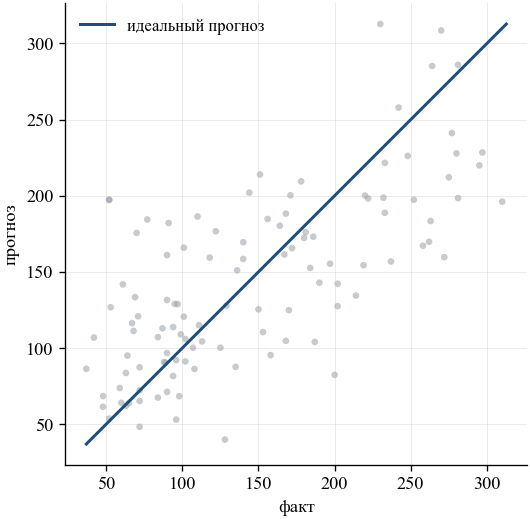

,Датасет,Модель,MSE,RMSE,R2,Параметры
0,Diabetes,Линейная,2848.3107,53.3696,0.4849,11
1,Diabetes,Аддитивная,2824.5313,53.1463,0.4892,81
2,Diabetes,Полная полиномиальная,3183.7634,56.4248,0.4242,66


In [12]:
diabetes = load_diabetes()
X_real_raw = diabetes.data.astype(float)
y_real = diabetes.target.astype(float)
X_real_train_raw, X_real_test_raw, y_real_train, y_real_test = train_test_split(
    X_real_raw, y_real, test_size=0.25, random_state=SEED
)
scaler = MinMaxScaler()
X_real_train = scaler.fit_transform(X_real_train_raw)
X_real_test = scaler.transform(X_real_test_raw)

real_lam = select_lambda(
    X_real_train,
    y_real_train,
    basis=bspline_basis,
    basis_name="bspline",
    M=M_REAL,
    seed=SEED,
)
real_additive_model = fit_additive(
    X_real_train,
    y_real_train,
    basis=bspline_basis,
    basis_name="bspline",
    M=M_REAL,
    lam=real_lam,
)
real_linear_theta = fit_linear(X_real_train, y_real_train)
real_full_theta, real_full_transformer = fit_full_poly(X_real_train, y_real_train, degree=2)
real_add_pred = predict_additive(real_additive_model, X_real_test)

real_metrics = pd.DataFrame([
    metric_record("Diabetes", "Линейная", y_real_test, predict_linear(real_linear_theta, X_real_test), real_linear_theta.size),
    metric_record("Diabetes", "Аддитивная", y_real_test, real_add_pred, real_additive_model.n_params),
    metric_record("Diabetes", "Полная полиномиальная", y_real_test, predict_full_poly(real_full_theta, real_full_transformer, X_real_test), real_full_theta.size),
])
model_metrics = pd.concat([model_metrics, real_metrics], ignore_index=True)
save_fig(plot_pred_vs_true(y_real_test, real_add_pred), "fig_pred_vs_true", raster=True)
format_metrics(real_metrics)


## Эксперимент 4. Неаддитивные данные

Истинная функция содержит взаимодействие $x_1 x_2$. Сравниваются аддитивная и полная полиномиальная модели; на поверхности остатков видна структура, которую аддитивный класс описать не может.


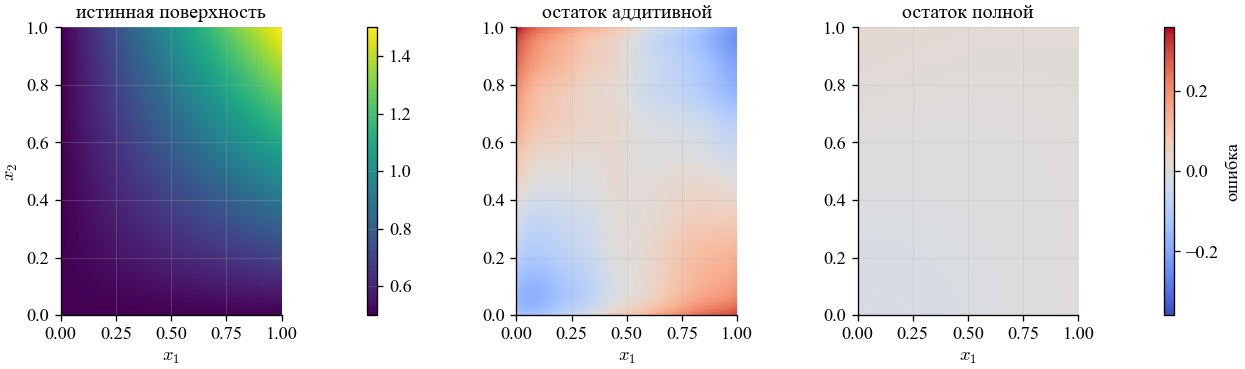

,Датасет,Модель,MSE,RMSE,R2,Параметры
0,Неаддитивные,Аддитивная,0.0125,0.1116,0.9045,37
1,Неаддитивные,Полная полиномиальная,0.0055,0.0744,0.9576,10


In [13]:
rng = np.random.default_rng(SEED + 7)
X_non, y_non, signal_non = make_nonadditive_data(N_NONADDITIVE, rng)
X_non_train, X_non_test, y_non_train, y_non_test = train_test_split(
    X_non, y_non, test_size=TEST_SIZE, random_state=SEED
)
non_lam = select_lambda(
    X_non_train,
    y_non_train,
    basis=bspline_basis,
    basis_name="bspline",
    M=M_MAIN,
    seed=SEED,
)
non_additive_model = fit_additive(
    X_non_train,
    y_non_train,
    basis=bspline_basis,
    basis_name="bspline",
    M=M_MAIN,
    lam=non_lam,
)
non_full_theta, non_full_transformer = fit_full_poly(X_non_train, y_non_train, degree=2)
nonadditive_metrics = pd.DataFrame([
    metric_record("Неаддитивные", "Аддитивная", y_non_test, predict_additive(non_additive_model, X_non_test), non_additive_model.n_params),
    metric_record("Неаддитивные", "Полная полиномиальная", y_non_test, predict_full_poly(non_full_theta, non_full_transformer, X_non_test), non_full_theta.size),
])
save_fig(plot_nonadditive(non_additive_model, non_full_theta, non_full_transformer), "fig_nonadditive")
format_metrics(nonadditive_metrics)


## Сводка результатов

Таблицы метрик и числовые показатели сохраняются в `assets/` и `case7_summary.json`; проверяется наличие всех артефактов отчёта.


In [14]:
model_metrics.to_csv(ASSETS_DIR / "tab_model_metrics.csv", index=False, encoding="utf-8")
nonadditive_metrics.to_csv(ASSETS_DIR / "tab_nonadditive.csv", index=False, encoding="utf-8")
basis_comparison.to_csv(ASSETS_DIR / "tab_basis_comparison.csv", index=False, encoding="utf-8")
error_vs_M.to_csv(ASSETS_DIR / "error_vs_M.csv", index=False, encoding="utf-8")

summary = {
    "seed": SEED,
    "additive_lambda": additive_lam,
    "real_lambda": real_lam,
    "nonadditive_lambda": non_lam,
    "centering_max_abs_sum": max_centering_error,
    "linear_equivalence_max_abs_diff": linear_difference,
    "model_metrics": model_metrics.to_dict(orient="records"),
    "nonadditive_metrics": nonadditive_metrics.to_dict(orient="records"),
    "basis_comparison": basis_comparison.to_dict(orient="records"),
    "best_M_by_test_rmse": int(error_vs_M.loc[error_vs_M["RMSE test"].idxmin(), "M"]),
}
with (ASSETS_DIR / "case7_summary.json").open("w", encoding="utf-8") as handle:
    json.dump(summary, handle, ensure_ascii=False, indent=2)

expected_assets = [
    "fig_true_components.svg",
    "fig_basis.svg",
    "fig_design_matrix.svg",
    "fig_recovered_components.svg",
    "fig_error_vs_M.svg",
    "fig_model_comparison.svg",
    "fig_pred_vs_true.png",
    "fig_nonadditive.svg",
    "tab_model_metrics.csv",
    "tab_nonadditive.csv",
    "tab_basis_comparison.csv",
    "case7_summary.json",
]
missing_assets = [name for name in expected_assets if not (ASSETS_DIR / name).exists()]
assert not missing_assets, missing_assets

artifact_df = pd.DataFrame({"Артефакт": expected_assets, "Создан": [True] * len(expected_assets)})
artifact_df


,Артефакт,Создан
0,fig_true_components.svg,True
1,fig_basis.svg,True
2,fig_design_matrix.svg,True
3,fig_recovered_components.svg,True
4,fig_error_vs_M.svg,True
5,fig_model_comparison.svg,True
6,fig_pred_vs_true.png,True
7,fig_nonadditive.svg,True
8,tab_model_metrics.csv,True
9,tab_nonadditive.csv,True


## Выводы

Аддитивная модель построена как линейная по параметрам задача МНК после выбора одномерного базиса: реализованы полиномиальный, тригонометрический и B-сплайновый базисы, блочная матрица $Z$, МНК, ridge без штрафа на свободный член, центрирование и восстановление компонент. На синтетических аддитивных данных получены RMSE $0{,}078$ и $R^2 = 0{,}989$, что лучше линейной модели и сопоставимо с полной полиномиальной при меньшем числе параметров; восстановленные компоненты согласуются с истинными. Эксперимент с $x_1 x_2 + x_3$ показывает границу применимости: при сильных взаимодействиях полная модель выигрывает, поэтому аддитивная модель целесообразна при покомпонентных нелинейностях.

Репозиторий: https://github.com/mezgou/itmo-functional-analysis-course
